In [1]:
# from google.colab import drive
# import requests
# import numpy as np
# import seaborn as sn

# drive.mount('/content/gdrive/')

In [2]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt

DATA_DIR = r"D:\deap-dataset\data_preprocessed_python"

def load_subject(subject_num):
    """Loads s01.dat, s02.dat, etc."""
    file_path = os.path.join(DATA_DIR, f's{subject_num:02d}.dat')
    with open(file_path, 'rb') as f:
        raw_data = pickle.load(f, encoding='latin1')
    eeg = raw_data['data'][:, :32, :]
    labels = raw_data['labels']
    
    return eeg, labels

eeg_s01, labels_s01 = load_subject(1)
print(f"EEG Shape: {eeg_s01.shape} (Trials, Channels, Samples)")
print(f"Labels Shape: {labels_s01.shape} (Trials, Valence/Arousal/Dominance/Liking)")

EEG Shape: (40, 32, 8064) (Trials, Channels, Samples)
Labels Shape: (40, 4) (Trials, Valence/Arousal/Dominance/Liking)


# Unzip

In [3]:
cd /content/gdrive/Shareddrives/GCPDS/databases/DEAP/

[WinError 3] The system cannot find the path specified: '/content/gdrive/Shareddrives/GCPDS/databases/DEAP/'
d:\deap-dataset


d:\miniconda\envs\eeg_env\lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [4]:
!unzip data_preprocessed_python

'unzip' is not recognized as an internal or external command,
operable program or batch file.


# load sub

The videos are in the order of Experiment_id, so not in the order of presentation. This means the first video is the same for each participant.

In [5]:
cd /content/gdrive/Shareddrives/GCPDS/databases/DEAP/

[WinError 3] The system cannot find the path specified: '/content/gdrive/Shareddrives/GCPDS/databases/DEAP/'
d:\deap-dataset


In [6]:
import pickle

In [7]:
i = 1
with open('data_preprocessed_python/s'+ '01' + '.dat', 'rb') as file:
  subject = pickle.load(file, encoding='latin1')

In [8]:
subject.keys()

dict_keys(['labels', 'data'])

In [9]:
subject['data'].shape

(40, 40, 8064)

In [10]:
subject['labels'].shape

(40, 4)

In [11]:
all_eeg = []
all_labels = []

for i in range(1, 33):
    eeg, labels = load_subject(i)
    all_eeg.append(eeg)
    all_labels.append(labels)
    if i % 8 == 0: print(f"Loaded {i}/32 subjects...")

X_all = np.array(all_eeg, dtype='float32') # Shape: (32, 40, 32, 8064)
y_all = np.array(all_labels, dtype='float32') # Shape: (32, 40, 4)

print(f"Total Data Shape: {X_all.shape} (Subjects, Trials, Channels, Samples)")

Loaded 8/32 subjects...
Loaded 16/32 subjects...
Loaded 24/32 subjects...
Loaded 32/32 subjects...
Total Data Shape: (32, 40, 32, 8064) (Subjects, Trials, Channels, Samples)


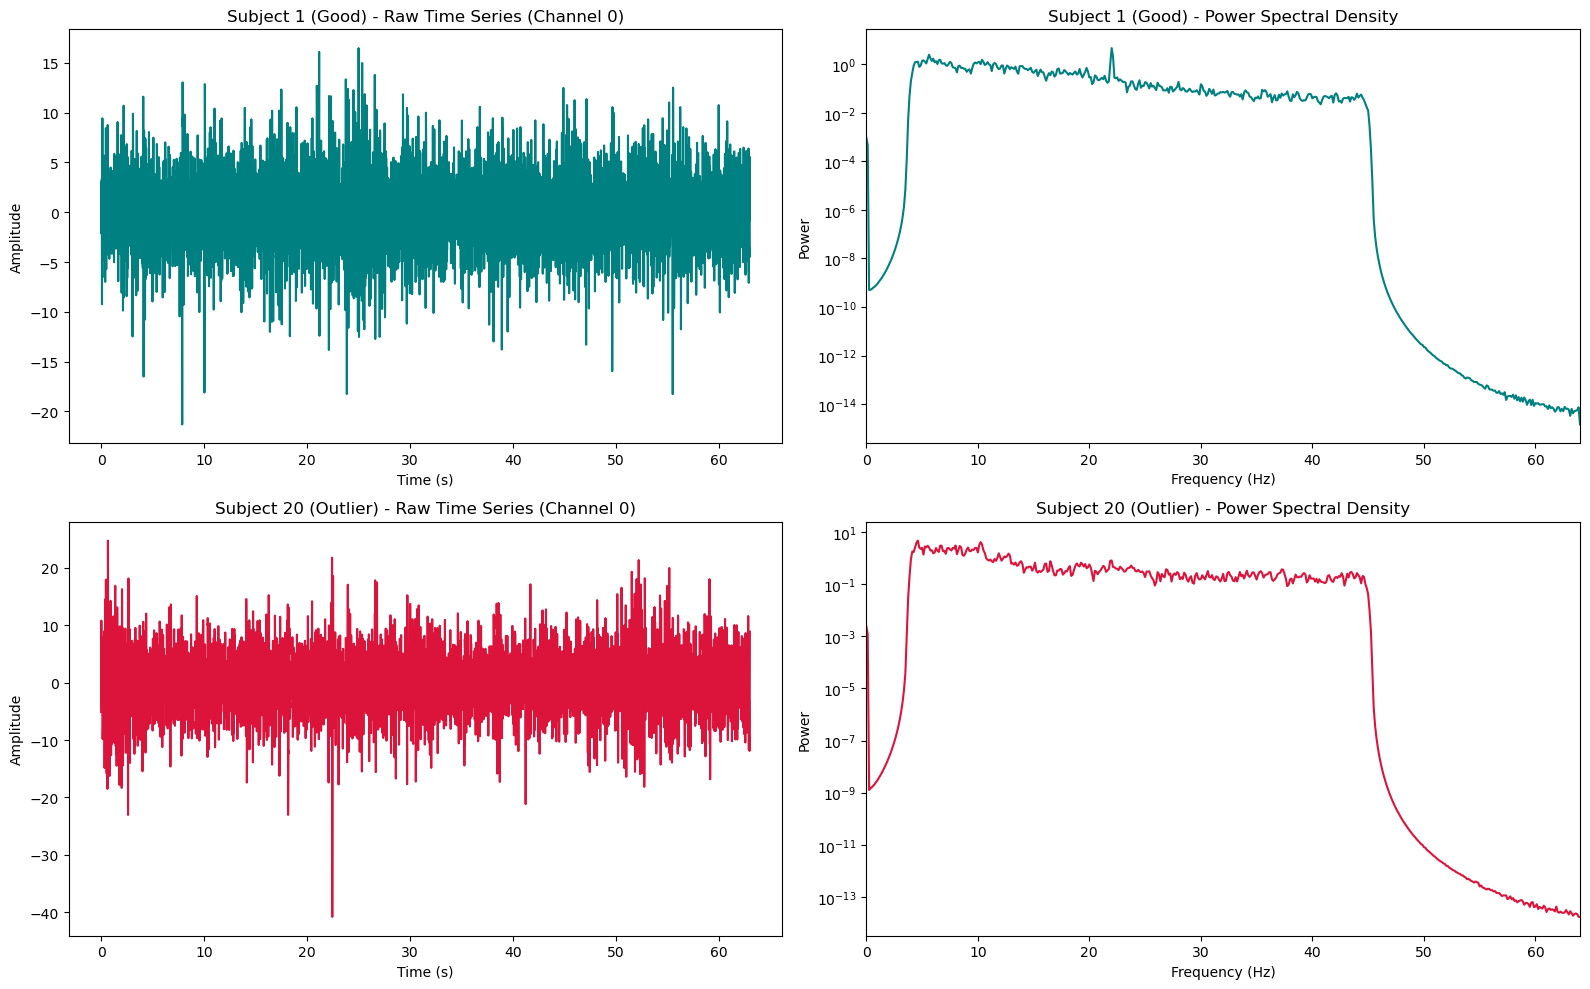

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def plot_subject_comparison(subj_a=1, subj_b=20, trial_idx=0, chan_idx=0):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    subjects = [subj_a, subj_b]
    names = [f"Subject {subj_a} (Good)", f"Subject {subj_b} (Outlier)"]
    for i, subj in enumerate(subjects):
        sig = X_all[subj-1, trial_idx, chan_idx, :]
        time = np.arange(len(sig)) / 128.0
        
        axes[i, 0].plot(time, sig, color='crimson' if i==1 else 'teal')
        axes[i, 0].set_title(f"{names[i]} - Raw Time Series (Channel {chan_idx})")
        axes[i, 0].set_ylabel("Amplitude")
        axes[i, 0].set_xlabel("Time (s)")
        freqs, psd = signal.welch(sig, 128, nperseg=1024)
        axes[i, 1].semilogy(freqs, psd, color='crimson' if i==1 else 'teal')
        axes[i, 1].set_title(f"{names[i]} - Power Spectral Density")
        axes[i, 1].set_ylabel("Power")
        axes[i, 1].set_xlabel("Frequency (Hz)")
        axes[i, 1].set_xlim(0, 64)

    plt.tight_layout()
    plt.show()

plot_subject_comparison(subj_a=1, subj_b=20)

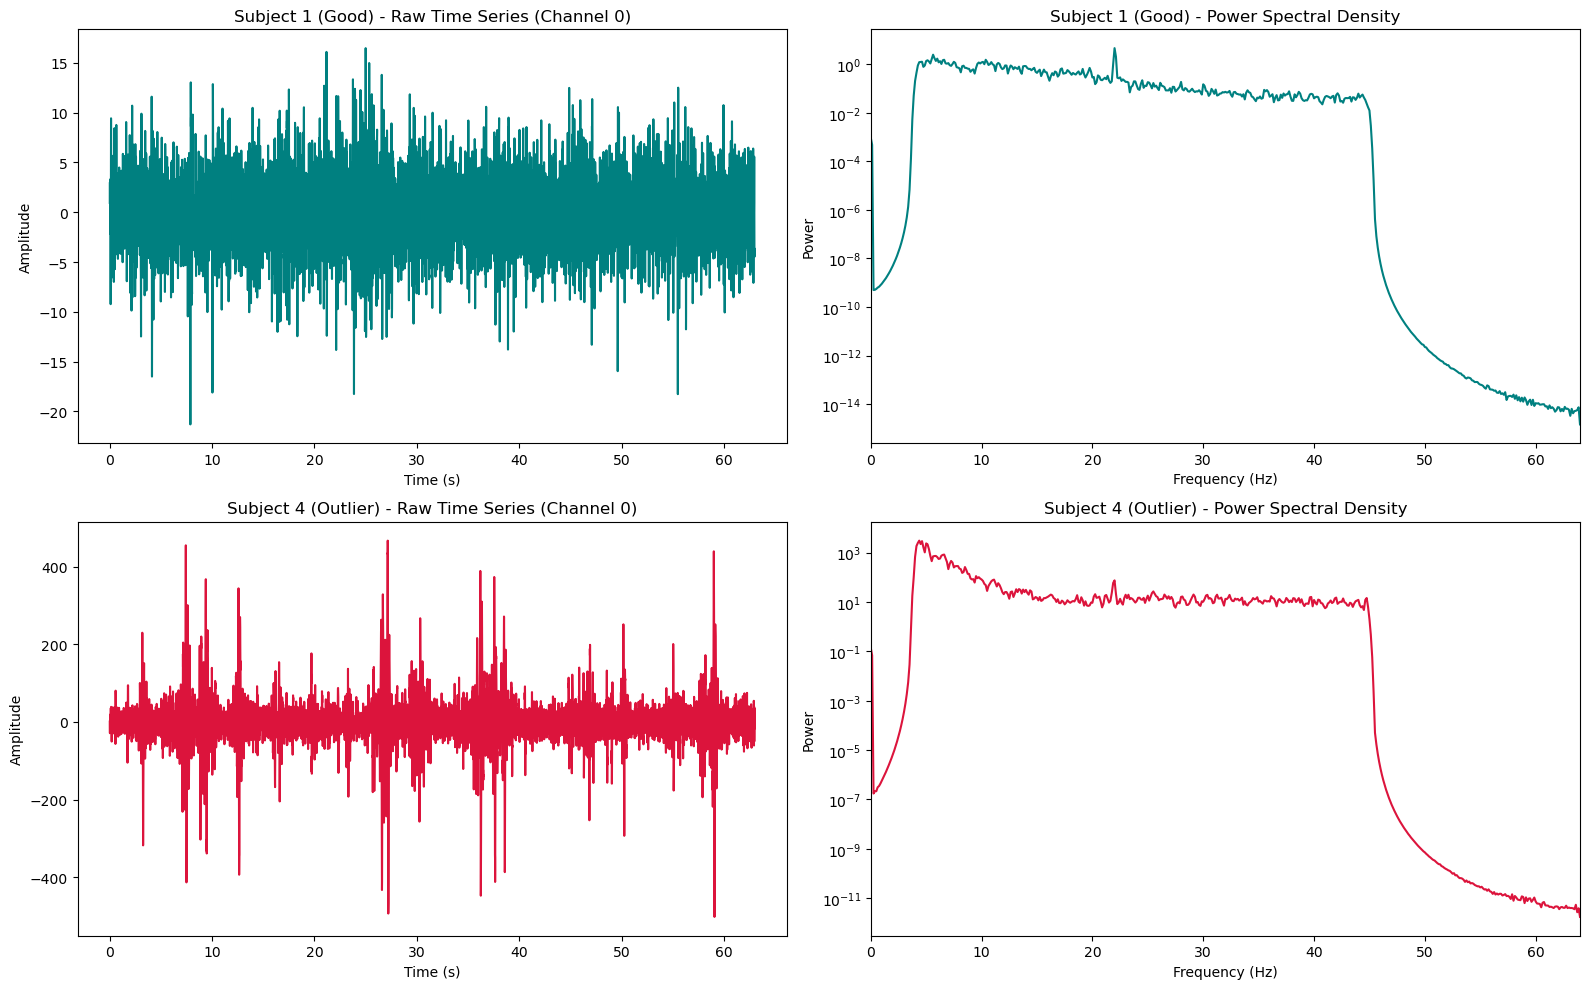

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def plot_subject_comparison(subj_a, subj_b, trial_idx=0, chan_idx=0):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    subjects = [subj_a, subj_b]
    names = [f"Subject {subj_a} (Good)", f"Subject {subj_b} (Outlier)"]
    for i, subj in enumerate(subjects):
        sig = X_all[subj-1, trial_idx, chan_idx, :]
        time = np.arange(len(sig)) / 128.0
        
        axes[i, 0].plot(time, sig, color='crimson' if i==1 else 'teal')
        axes[i, 0].set_title(f"{names[i]} - Raw Time Series (Channel {chan_idx})")
        axes[i, 0].set_ylabel("Amplitude")
        axes[i, 0].set_xlabel("Time (s)")
        freqs, psd = signal.welch(sig, 128, nperseg=1024)
        axes[i, 1].semilogy(freqs, psd, color='crimson' if i==1 else 'teal')
        axes[i, 1].set_title(f"{names[i]} - Power Spectral Density")
        axes[i, 1].set_ylabel("Power")
        axes[i, 1].set_xlabel("Frequency (Hz)")
        axes[i, 1].set_xlim(0, 64)

    plt.tight_layout()
    plt.show()

plot_subject_comparison(subj_a=1, subj_b=4)

In [14]:
# Drop Subject 4 (proven in Outlier Analysis EDA)
subjects_to_drop = [3] # Index 3 is Subject 4
X_all = np.delete(X_all, subjects_to_drop, axis=0)
y_all = np.delete(y_all, subjects_to_drop, axis=0)
groups = np.repeat(np.arange(31), 40)

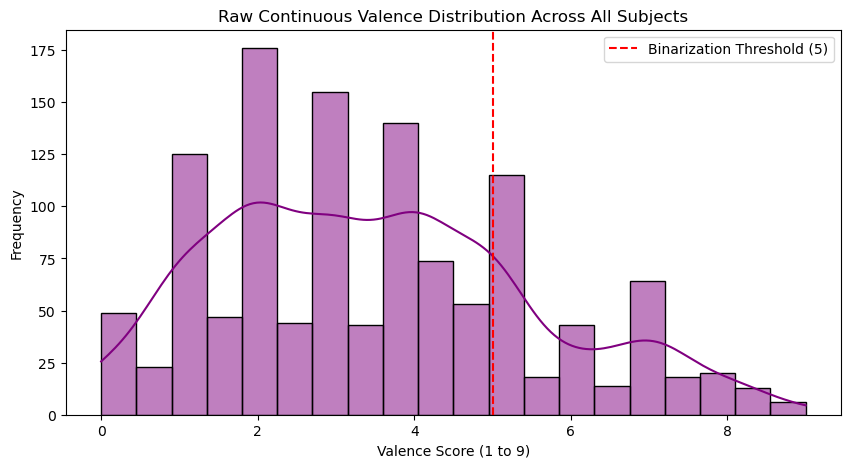

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

raw_valence = y_all[:, :, 0].flatten()

plt.figure(figsize=(10, 5))
sns.histplot(raw_valence, bins=20, kde=True, color='purple')
plt.axvline(x=5, color='red', linestyle='--', label='Binarization Threshold (5)')
plt.title("Raw Continuous Valence Distribution Across All Subjects")
plt.xlabel("Valence Score (1 to 9)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

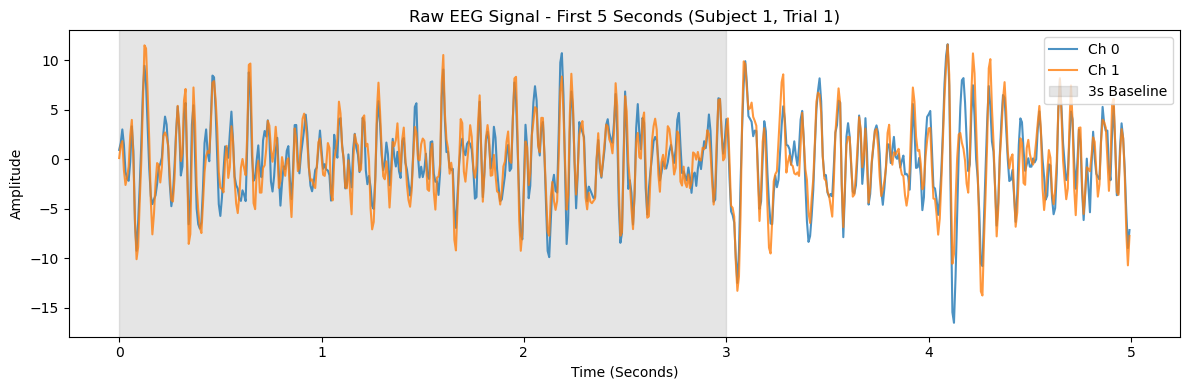

In [16]:
subject_idx, trial_idx = 0, 0
channel_1, channel_2 = 0, 1 

time_axis = np.arange(640) / 128.0 

plt.figure(figsize=(12, 4))
plt.plot(time_axis, X_all[subject_idx, trial_idx, channel_1, :640], label="Ch 0", alpha=0.8)
plt.plot(time_axis, X_all[subject_idx, trial_idx, channel_2, :640], label="Ch 1", alpha=0.8)

plt.axvspan(0, 3, color='gray', alpha=0.2, label='3s Baseline')
plt.title("Raw EEG Signal - First 5 Seconds (Subject 1, Trial 1)")
plt.xlabel("Time (Seconds)")
plt.ylabel("Amplitude")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [17]:
y_valence_raw = y_all[:, :, 0]
y_bin = (y_valence_raw > 5).astype(np.float32).reshape(-1)

In [18]:
def apply_zhao_preprocessing(X):
    baseline = X[:, :, :, :384]
    task = X[:, :, :, 384:]
    baseline_mean = np.mean(baseline, axis=-1, keepdims=True)
    return task - baseline_mean

X_zhao = apply_zhao_preprocessing(X_all)

In [19]:
y_valence_raw = y_all[:, :, 0] # Extract Valence
y_flat_bin = (y_valence_raw > 5).astype(np.float32).reshape(-1)
print(f"Target Array (y_bin): {y_flat_bin.shape}")

Target Array (y_bin): (1240,)


In [20]:
X_flat_zhao = X_zhao.reshape(-1, 32, 7680)
X_cnn_input = X_flat_zhao
num_trials = X_flat_zhao.shape[0] 
X_lstm_input = np.zeros((num_trials, 32, 32), dtype=np.float32)

for i in range(num_trials):
    X_lstm_input[i] = np.corrcoef(X_flat_zhao[i])
    
groups = np.repeat(np.arange(31), 40)
print(f"Target Array (y_bin): {y_flat_bin.shape}")
print(f"CNN Features (X_cnn_input): {X_cnn_input.shape}")
print(f"LSTM Features (X_lstm_input): {X_lstm_input.shape}")

Target Array (y_bin): (1240,)
CNN Features (X_cnn_input): (1240, 32, 7680)
LSTM Features (X_lstm_input): (1240, 32, 32)


C:\Users\dell\AppData\Local\Temp\ipykernel_35576\1671553691.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_bin, palette="Set2", ax=axes[0])


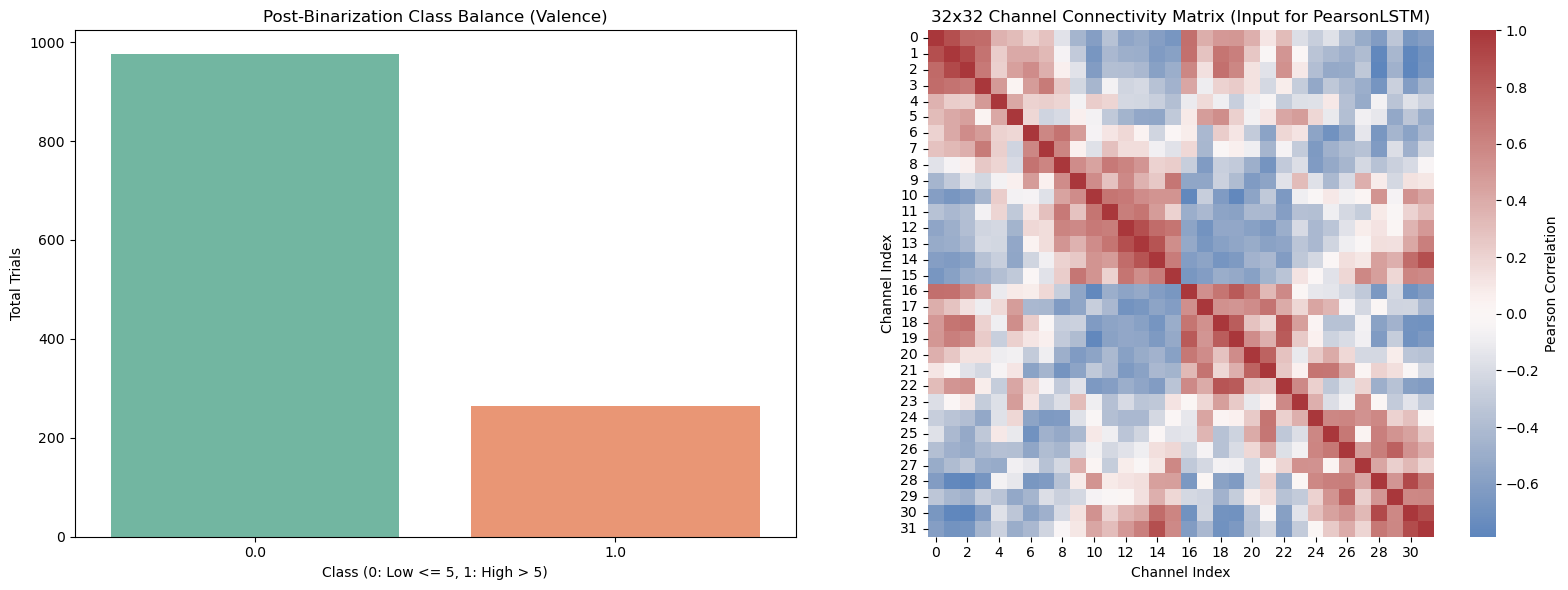

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(x=y_bin, palette="Set2", ax=axes[0])
axes[0].set_title("Post-Binarization Class Balance (Valence)")
axes[0].set_xlabel("Class (0: Low <= 5, 1: High > 5)")
axes[0].set_ylabel("Total Trials")

single_trial_matrix = X_lstm_input[0]
sns.heatmap(single_trial_matrix, cmap="vlag", center=0, square=True, 
            cbar_kws={'label': 'Pearson Correlation'}, ax=axes[1])
axes[1].set_title("32x32 Channel Connectivity Matrix (Input for PearsonLSTM)")
axes[1].set_xlabel("Channel Index")
axes[1].set_ylabel("Channel Index")

plt.tight_layout()
plt.show()

In [22]:
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
num_subjects = X_all.shape[0] # This will be 31
groups = np.repeat(np.arange(num_subjects), 40)
X_flat = X_all.reshape(-1, 32, 8064)
y_flat = y_all[:, :, 0].reshape(-1) # Taking Valence labels (index 0)
for train_idx, test_idx in logo.split(X_flat, y_flat, groups):
    X_train, X_test = X_flat[train_idx], X_flat[test_idx]
    y_train, y_test = y_flat[train_idx], y_flat[test_idx]
    print(f"Training on {num_subjects - 1} people... Testing on Subject {groups[test_idx][0] + 1}")
    break

Training on 30 people... Testing on Subject 1


In [23]:
import torch.nn as nn

class PearsonLSTM(nn.Module):
    def __init__(self, input_size=32, hidden_size=64, num_layers=2):
        super(PearsonLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

model_jin = PearsonLSTM().cuda()
print(model_jin)

PearsonLSTM(
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [24]:
class ZhaoCNN(nn.Module):
    def __init__(self):
        super(ZhaoCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=125)
        self.pool = nn.MaxPool1d(kernel_size=4)
        self.dropout = nn.Dropout(0.3) 
        self.fc1 = nn.Linear(64 * 1889, 128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.sigmoid(self.fc2(x))
        return x

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
class PearsonLSTM(nn.Module):
    def __init__(self, input_size=32, hidden_size=64, num_layers=2):
        super(PearsonLSTM, self).__init__()
        # Adding dropout=0.3 to the LSTM layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                            batch_first=True, dropout=0.3)
        self.dropout = nn.Dropout(0.3) 
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :]) 
        out = self.fc(out)
        return self.sigmoid(out)

optimizer = torch.optim.Adam(model_jin.parameters(), lr=0.001, weight_decay=1e-4)

In [26]:
import torch.optim as optim
import pandas as pd
import numpy as np

y_flat_bin = (y_all[:, :, 0] > 5).astype(float).reshape(-1)
X_flat = X_all.reshape(-1, 32, 8064)
groups = np.repeat(np.arange(32), 40)

final_results = []

model_jin = PearsonLSTM(input_size=32).cuda()
optimizer = optim.Adam(model_jin.parameters(), lr=0.001)
criterion = nn.BCELoss()
num_subjects = X_all.shape[0] 
groups = np.repeat(np.arange(num_subjects), 40)

for train_idx, test_idx in logo.split(X_flat, y_flat_bin, groups):
    subject_id = groups[test_idx][0] + 1
    y_train = torch.tensor(y_flat_bin[train_idx], dtype=torch.float32).unsqueeze(1).cuda()
    X_train_raw = X_flat[train_idx]
    X_train_pearson = torch.tensor(np.array([np.corrcoef(t) for t in X_train_raw]), dtype=torch.float32).cuda()
    model_jin.train()
    for epoch in range(20): 
        optimizer.zero_grad()
        outputs = model_jin(X_train_pearson)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
    
    model_jin.eval()
    with torch.no_grad():
        X_test_raw = X_flat[test_idx]
        y_test = torch.tensor(y_flat_bin[test_idx], dtype=torch.float32).unsqueeze(1).cuda()
        X_test_pearson = torch.tensor(np.array([np.corrcoef(t) for t in X_test_raw]), dtype=torch.float32).cuda()
        
        preds = (model_jin(X_test_pearson) > 0.5).float()
        acc = (preds == y_test).float().mean().item()
        
        print(f"Subject {subject_id}: Accuracy = {acc*100:.2f}%")
        final_results.append({'Subject': subject_id, 'Accuracy': acc})

avg_acc = np.mean([r['Accuracy'] for r in final_results])
print(f"\nSubject-Independent Mean Accuracy: {avg_acc*100:.2f}%")

Subject 1: Accuracy = 85.00%
Subject 2: Accuracy = 85.00%
Subject 3: Accuracy = 47.50%
Subject 4: Accuracy = 72.50%
Subject 5: Accuracy = 57.50%
Subject 6: Accuracy = 75.00%
Subject 7: Accuracy = 80.00%
Subject 8: Accuracy = 87.50%
Subject 9: Accuracy = 77.50%
Subject 10: Accuracy = 62.50%
Subject 11: Accuracy = 95.00%
Subject 12: Accuracy = 95.00%
Subject 13: Accuracy = 80.00%
Subject 14: Accuracy = 70.00%
Subject 15: Accuracy = 85.00%
Subject 16: Accuracy = 77.50%
Subject 17: Accuracy = 82.50%
Subject 18: Accuracy = 90.00%
Subject 19: Accuracy = 85.00%
Subject 20: Accuracy = 95.00%
Subject 21: Accuracy = 85.00%
Subject 22: Accuracy = 67.50%
Subject 23: Accuracy = 90.00%
Subject 24: Accuracy = 87.50%
Subject 25: Accuracy = 92.50%
Subject 26: Accuracy = 85.00%
Subject 27: Accuracy = 75.00%
Subject 28: Accuracy = 92.50%
Subject 29: Accuracy = 75.00%
Subject 30: Accuracy = 62.50%
Subject 31: Accuracy = 75.00%

Subject-Independent Mean Accuracy: 79.76%


In [27]:
from torch.utils.data import DataLoader, TensorDataset
cnn_results = []
for train_idx, test_idx in logo.split(X_cnn_input, y_flat_bin, groups):
    subject_id = groups[test_idx][0] + 1
    X_train_cpu = torch.tensor(X_cnn_input[train_idx], dtype=torch.float32)
    y_train_cpu = torch.tensor(y_flat_bin[train_idx], dtype=torch.float32).unsqueeze(1)
    train_loader = DataLoader(TensorDataset(X_train_cpu, y_train_cpu), batch_size=64, shuffle=True)
    model_zhao = ZhaoCNN().cuda()
    optimizer_zhao = optim.Adam(model_zhao.parameters(), lr=0.0005)
    criterion = nn.BCELoss()
    model_zhao.train()
    for epoch in range(15):
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.cuda(), batch_y.cuda()
            
            optimizer_zhao.zero_grad()
            outputs = model_zhao(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer_zhao.step()
            
    # 4. Evaluation Loop
    model_zhao.eval()
    with torch.no_grad():
        X_test = torch.tensor(X_cnn_input[test_idx], dtype=torch.float32).cuda()
        y_test = torch.tensor(y_flat_bin[test_idx], dtype=torch.float32).unsqueeze(1).cuda()
        preds = (model_zhao(X_test) > 0.5).float()
        acc = (preds == y_test).float().mean().item()
        
    print(f"Subject {subject_id} Accuracy: {acc*100:.2f}%")
    cnn_results.append({'Subject': subject_id, 'Accuracy': acc})

cnn_avg_acc = np.mean([r['Accuracy'] for r in cnn_results])
print(f"\nZhaoCNN Subject-Independent Mean Accuracy: {cnn_avg_acc*100:.2f}%")

Subject 1 Accuracy: 85.00%
Subject 2 Accuracy: 15.00%
Subject 3 Accuracy: 47.50%
Subject 4 Accuracy: 72.50%
Subject 5 Accuracy: 42.50%
Subject 6 Accuracy: 75.00%
Subject 7 Accuracy: 80.00%
Subject 8 Accuracy: 87.50%
Subject 9 Accuracy: 77.50%
Subject 10 Accuracy: 62.50%
Subject 11 Accuracy: 95.00%
Subject 12 Accuracy: 95.00%
Subject 13 Accuracy: 80.00%
Subject 14 Accuracy: 70.00%
Subject 15 Accuracy: 85.00%
Subject 16 Accuracy: 77.50%
Subject 17 Accuracy: 82.50%
Subject 18 Accuracy: 87.50%
Subject 19 Accuracy: 85.00%
Subject 20 Accuracy: 95.00%
Subject 21 Accuracy: 85.00%
Subject 22 Accuracy: 60.00%
Subject 23 Accuracy: 90.00%
Subject 24 Accuracy: 87.50%
Subject 25 Accuracy: 25.00%
Subject 26 Accuracy: 85.00%
Subject 27 Accuracy: 75.00%
Subject 28 Accuracy: 87.50%
Subject 29 Accuracy: 75.00%
Subject 30 Accuracy: 60.00%
Subject 31 Accuracy: 75.00%

ZhaoCNN Subject-Independent Mean Accuracy: 74.27%


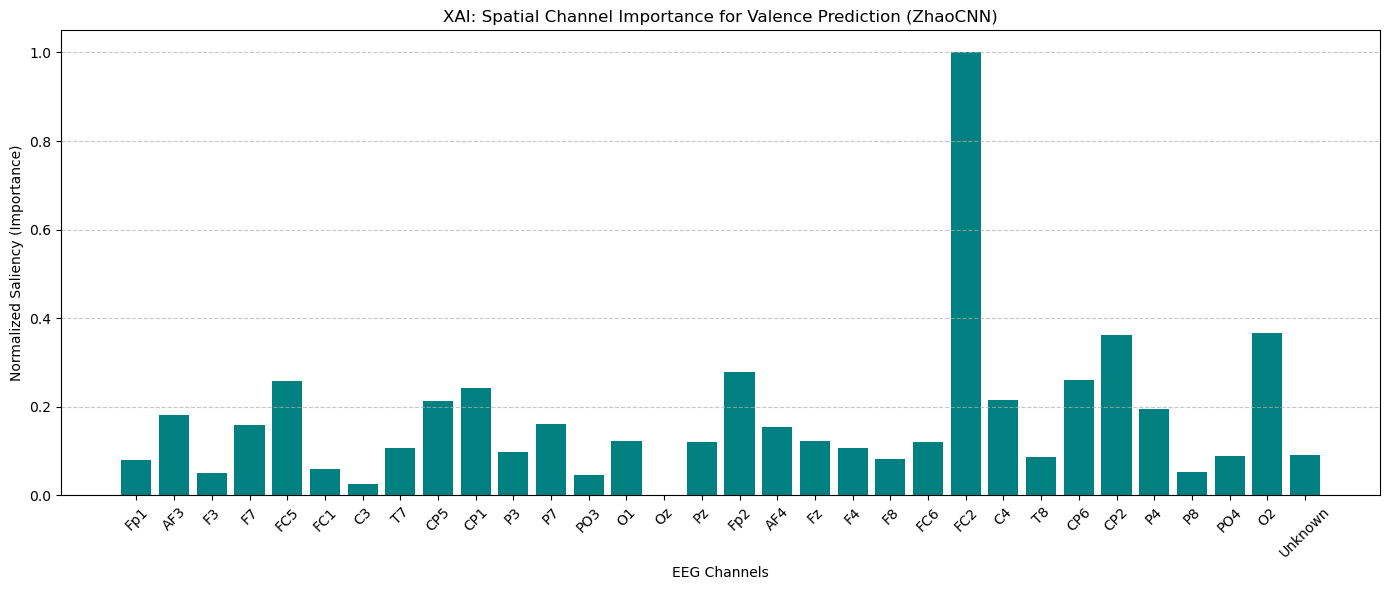

In [28]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def get_eeg_channel_importance(model, x):
    model.eval()
    x.requires_grad_()
    # Forward pass
    output = model(x)
    output.backward(torch.ones_like(output))
    gradients = x.grad.abs()
    channel_importance = gradients.mean(dim=(0, 2))
    channel_importance = (channel_importance - channel_importance.min()) / \
                         (channel_importance.max() - channel_importance.min())
    return channel_importance.cpu().detach().numpy()

X_test_xai = torch.tensor(X_cnn_input[test_idx], dtype=torch.float32).cuda()
original_activation = model_zhao.sigmoid
model_zhao.sigmoid = nn.Identity()


importances = get_eeg_channel_importance(model_zhao, X_test_xai)
model_zhao.sigmoid = original_activation

deap_channels = ['Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 
                 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz', 'Fp2', 'AF4', 'Fz', 'F4', 
                 'F8', 'FC6', 'FC2', 'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'Unknown']

plt.figure(figsize=(14, 6))
plt.bar(deap_channels[:32], importances, color='teal')
plt.title("XAI: Spatial Channel Importance for Valence Prediction (ZhaoCNN)")
plt.ylabel("Normalized Saliency (Importance)")
plt.xlabel("EEG Channels")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
!pip install shap

In [31]:
model_jin.train()
shap_values = explainer.shap_values(test_samples)
model_jin.eval()
mean_shap = np.abs(shap_values[0]).mean(axis=0)

NameError: name 'explainer' is not defined

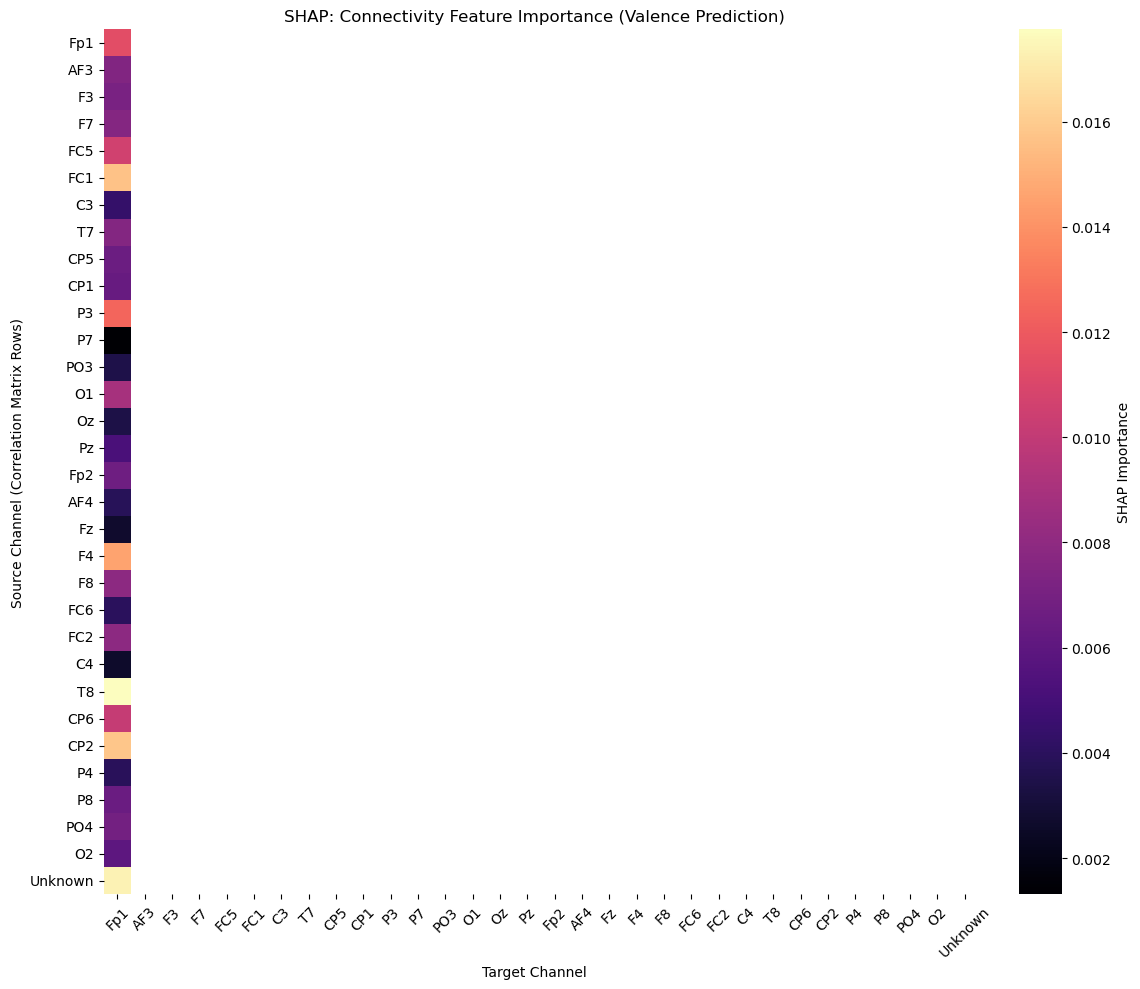

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(mean_shap, 
            xticklabels=deap_channels[:32], 
            yticklabels=deap_channels[:32], 
            cmap='magma', 
            cbar_kws={'label': 'SHAP Importance'})

plt.title("SHAP: Connectivity Feature Importance (Valence Prediction)")
plt.xlabel("Target Channel")
plt.ylabel("Source Channel (Correlation Matrix Rows)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

train_ds = TensorDataset(
    torch.tensor(X_lstm_input[train_idx], dtype=torch.float32), 
    torch.tensor(y_flat_bin[train_idx], dtype=torch.float32)
)

val_ds = TensorDataset(
    torch.tensor(X_lstm_input[test_idx], dtype=torch.float32), 
    torch.tensor(y_flat_bin[test_idx], dtype=torch.float32)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)


In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

num_epochs = 40 #

for epoch in range(num_epochs):
    model_jin.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.cuda(), batch_y.cuda()
        
        optimizer.zero_grad()
        outputs = model_jin(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = (outputs > 0.5).float()
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)

    model_jin.eval()
    v_loss_total, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.cuda(), batch_y.cuda()
            outputs = model_jin(batch_X).squeeze()
            
            v_loss = criterion(outputs, batch_y)
            v_loss_total += v_loss.item()
            preds = (outputs > 0.5).float()
            v_correct += (preds == batch_y).sum().item()
            v_total += batch_y.size(0)
            
    val_losses.append(v_loss_total / len(val_loader))
    val_accs.append(v_correct / v_total)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Acc: {train_accs[-1]:.2%} | Val Acc: {val_accs[-1]:.2%}")

Epoch [5/40] | Train Acc: 78.83% | Val Acc: 75.00%
Epoch [10/40] | Train Acc: 79.25% | Val Acc: 75.00%
Epoch [15/40] | Train Acc: 78.92% | Val Acc: 75.00%
Epoch [20/40] | Train Acc: 78.83% | Val Acc: 75.00%
Epoch [25/40] | Train Acc: 78.75% | Val Acc: 75.00%
Epoch [30/40] | Train Acc: 78.75% | Val Acc: 75.00%
Epoch [35/40] | Train Acc: 78.83% | Val Acc: 75.00%
Epoch [40/40] | Train Acc: 79.58% | Val Acc: 75.00%


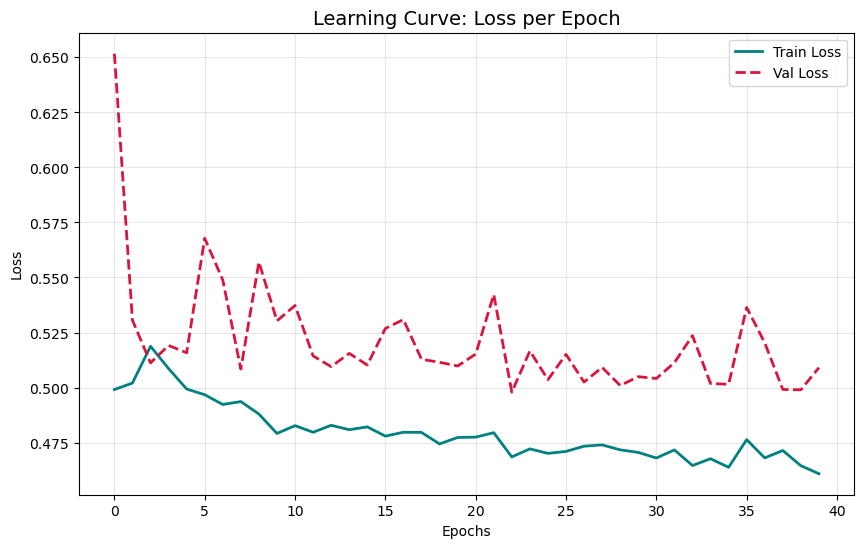

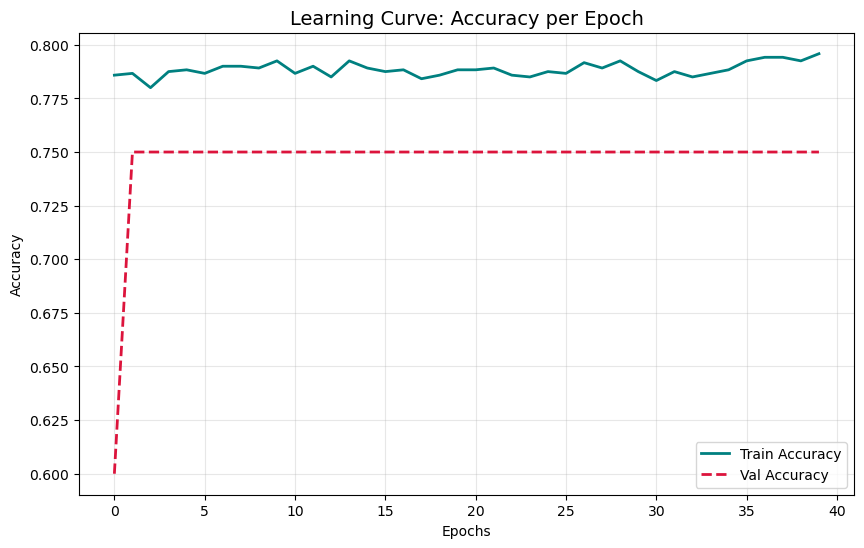

In [ ]:
plot_learning_curves(train_losses, val_losses, "Loss")
plot_learning_curves(train_accs, val_accs, "Accuracy")

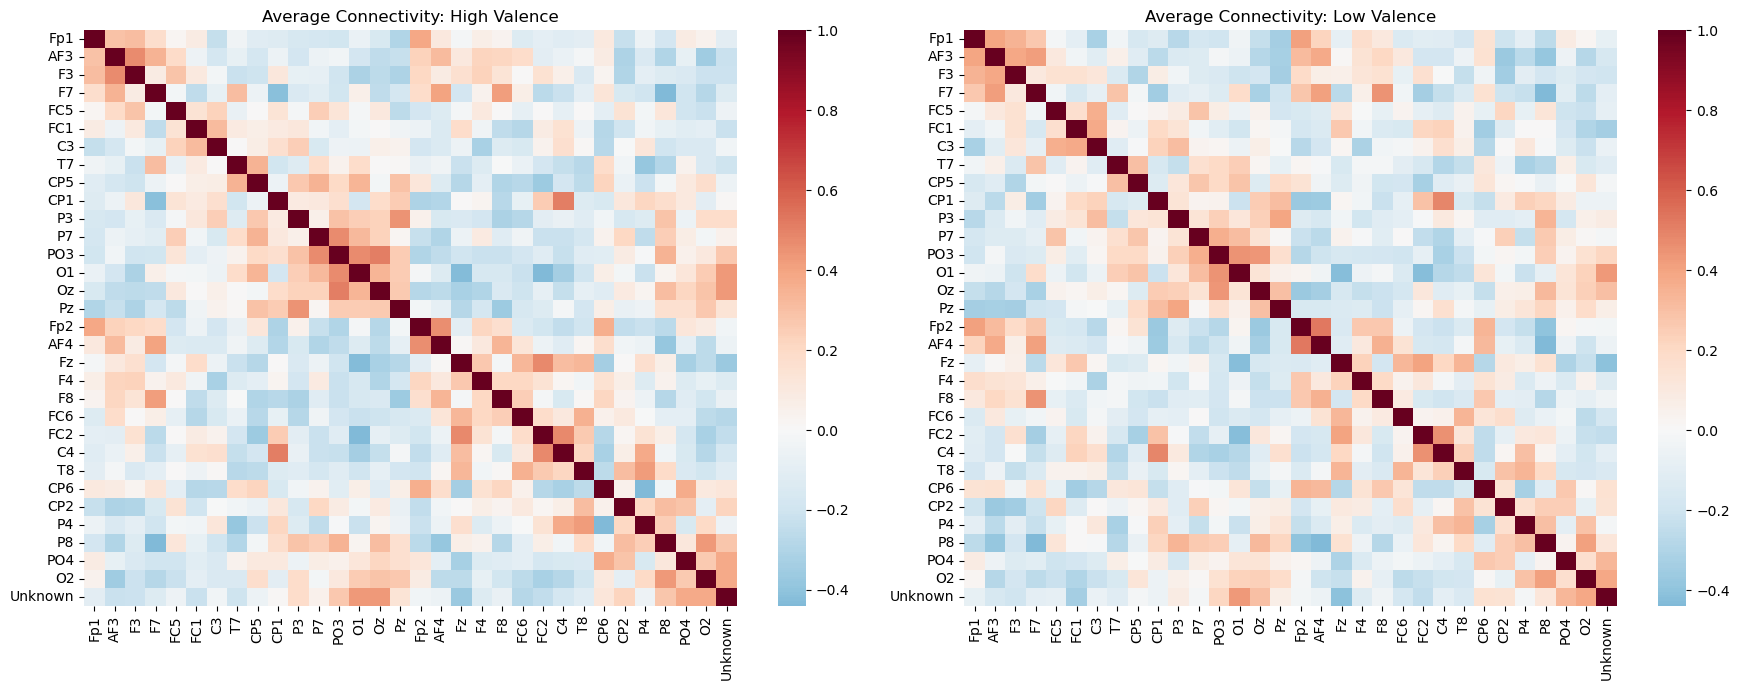

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

high_valence_idx = np.where(y_flat_bin == 1)[0]
low_valence_idx = np.where(y_flat_bin == 0)[0]
mean_high = np.mean(X_lstm_input[high_valence_idx], axis=0)
mean_low = np.mean(X_lstm_input[low_valence_idx], axis=0)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(mean_high, ax=axes[0], cmap='RdBu_r', center=0, 
            xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[0].set_title("Average Connectivity: High Valence")

sns.heatmap(mean_low, ax=axes[1], cmap='RdBu_r', center=0, 
            xticklabels=deap_channels[:32], yticklabels=deap_channels[:32])
axes[1].set_title("Average Connectivity: Low Valence")

plt.tight_layout()
plt.show()

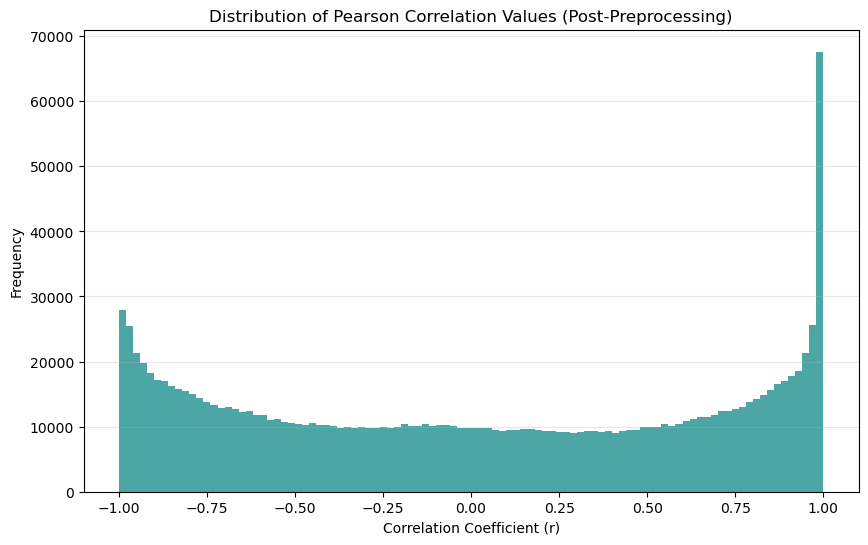

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(X_lstm_input.flatten(), bins=100, color='teal', alpha=0.7)
plt.title("Distribution of Pearson Correlation Values (Post-Preprocessing)")
plt.xlabel("Correlation Coefficient (r)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

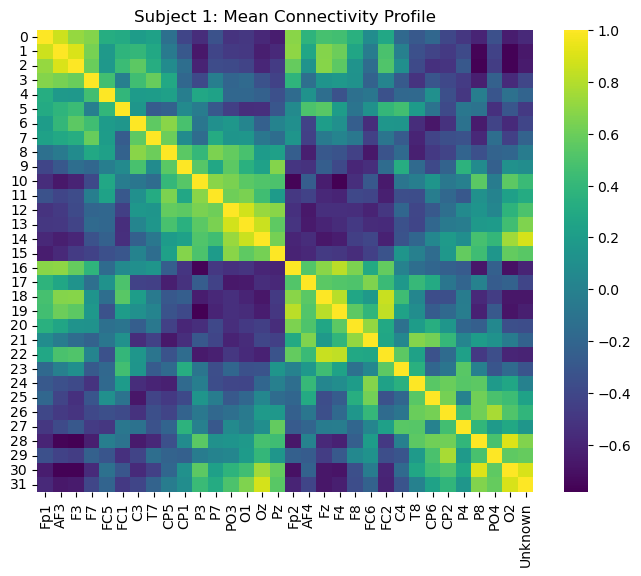

In [ ]:
subj1_mean = np.mean(X_lstm_input[:40], axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(subj1_mean, cmap='viridis', xticklabels=deap_channels[:32])
plt.title("Subject 1: Mean Connectivity Profile")
plt.show()

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import LeaveOneGroupOut
import numpy as np
import matplotlib.pyplot as plt


def create_hybrid_model(in_channels=32, cnn_filters=[64, 128], kernel_size=25,
                        pool_size=4, lstm_hidden=128, lstm_layers=2,
                        num_heads=4, dropout=0.3):
    """
    Creates all the layers for the CNN-BiLSTM-MHSA model.
    Returns a dictionary of layers + a list of all parameters.
    """
    conv1 = nn.Conv1d(in_channels, cnn_filters[0], kernel_size, padding=kernel_size//2)
    bn1 = nn.BatchNorm1d(cnn_filters[0])
    pool1 = nn.MaxPool1d(pool_size)

    conv2 = nn.Conv1d(cnn_filters[0], cnn_filters[1], kernel_size, padding=kernel_size//2)
    bn2 = nn.BatchNorm1d(cnn_filters[1])
    pool2 = nn.MaxPool1d(pool_size)
    bilstm = nn.LSTM(
        input_size=cnn_filters[1],
        hidden_size=lstm_hidden,
        num_layers=lstm_layers,
        batch_first=True,
        bidirectional=True,
        dropout=dropout if lstm_layers > 1 else 0
    )

    attention = nn.MultiheadAttention(
        embed_dim=lstm_hidden * 2,
        num_heads=num_heads,
        dropout=dropout,
        batch_first=True
    )

    drop = nn.Dropout(dropout)
    fc = nn.Linear(lstm_hidden * 2, 1)

    layers = {
        'conv1': conv1, 'bn1': bn1, 'pool1': pool1,
        'conv2': conv2, 'bn2': bn2, 'pool2': pool2,
        'bilstm': bilstm,
        'attention': attention,
        'drop': drop, 'fc': fc
    }

    all_params = []
    for layer in layers.values():
        all_params.extend(layer.parameters())

    return layers, all_params


def forward_pass(x, layers):
    """
    Runs one forward pass through the model.
    x shape: (batch, 32 channels, 8064 time samples)
    """
    x = torch.relu(layers['bn1'](layers['conv1'](x)))  # (batch, 64, 8064)
    x = layers['pool1'](x)                               # (batch, 64, 2016)
    x = torch.relu(layers['bn2'](layers['conv2'](x)))  # (batch, 128, 2016)
    x = layers['pool2'](x)                               # (batch, 128, 504)
    x = x.permute(0, 2, 1)                               # (batch, 504, 128)
    x, _ = layers['bilstm'](x)                           # (batch, 504, 256)
    x, _ = layers['attention'](x, x, x)                  # (batch, 504, 256)
    x = x.mean(dim=1)                                    # (batch, 256)
    x = layers['drop'](x)
    x = torch.sigmoid(layers['fc'](x))                   # (batch, 1)

    return x


def set_train_mode(layers):
    """Put all layers in training mode."""
    for layer in layers.values():
        layer.train()


def set_eval_mode(layers):
    """Put all layers in evaluation mode."""
    for layer in layers.values():
        layer.eval()


def move_to_gpu(layers):
    """Move all layers to GPU."""
    for name in layers:
        layers[name] = layers[name].cuda()


test_layers, test_params = create_hybrid_model()
move_to_gpu(test_layers)
total_params = sum(p.numel() for p in test_params)
print(f'Total parameters: {total_params:,}')
print(f'Layers: {list(test_layers.keys())}')


def forward_pass_with_attention(x, layers):
    """
    Same as forward_pass, but also returns attention weights.
    Use this for interpretability / visualization.
    """
    x = torch.relu(layers['bn1'](layers['conv1'](x)))
    x = layers['pool1'](x)
    x = torch.relu(layers['bn2'](layers['conv2'](x)))
    x = layers['pool2'](x)

    x = x.permute(0, 2, 1)
    x, _ = layers['bilstm'](x)

    attn_out, attn_weights = layers['attention'](x, x, x)
    pooled = attn_out.mean(dim=1)
    pooled = layers['drop'](pooled)
    output = torch.sigmoid(layers['fc'](pooled))

    return output, attn_weights


def compute_saliency(x, layers):
    """
    Computes gradient-based saliency map for EEG channel importance.
    Shows which channels contribute most to the prediction.
    """
    x_input = x.clone().detach().requires_grad_(True)
    set_eval_mode(layers)

    output = forward_pass(x_input, layers)
    output.backward(torch.ones_like(output))
    saliency = x_input.grad.abs()  # (batch, 32, 8064)
    channel_importance = saliency.mean(dim=2)  # (batch, 32)

    return channel_importance


print('Interpretability functions added:')
print('  - forward_pass_with_attention(x, layers) -> output, attn_weights')
print('  - compute_saliency(x, layers) -> channel_importance')

Total parameters: 1,179,457
Layers: ['conv1', 'bn1', 'pool1', 'conv2', 'bn2', 'pool2', 'bilstm', 'attention', 'drop', 'fc']
Interpretability functions added:
  - forward_pass_with_attention(x, layers) -> output, attn_weights
  - compute_saliency(x, layers) -> channel_importance


In [35]:

LEARNING_RATE = 0.0005    
WEIGHT_DECAY = 1e-4      
EPOCHS = 20               
BATCH_SIZE = 64          

CNN_FILTERS = [64, 128]   
KERNEL_SIZE = 25          
POOL_SIZE = 4             
LSTM_HIDDEN = 128         
LSTM_LAYERS = 2           
NUM_HEADS = 4       
DROPOUT = 0.3    

print('Hyperparameters configured!')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Weight decay: {WEIGHT_DECAY}')
print(f'  Epochs: {EPOCHS}')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  CNN filters: {CNN_FILTERS}')
print(f'  LSTM hidden: {LSTM_HIDDEN}')
print(f'  Attention heads: {NUM_HEADS}')
print(f'  Dropout: {DROPOUT}')

Hyperparameters configured!
  Learning rate: 0.0005
  Weight decay: 0.0001
  Epochs: 20
  Batch size: 64
  CNN filters: [64, 128]
  LSTM hidden: 128
  Attention heads: 4
  Dropout: 0.3


In [36]:
num_subjects = X_all.shape[0]
X_flat_hybrid = X_all.reshape(-1, 32, 8064)
y_flat_bin_hybrid = (y_all[:, :, 0] > 5).astype(float).reshape(-1)
groups_hybrid = np.repeat(np.arange(num_subjects), 40)

logo = LeaveOneGroupOut()
hybrid_results = []

print('CNN-BiLSTM-MHSA: Leave-One-Subject-Out Evaluation')

for fold_idx, (train_idx, test_idx) in enumerate(
    logo.split(X_flat_hybrid, y_flat_bin_hybrid, groups_hybrid)
):
    subject_id = groups_hybrid[test_idx][0] + 1
    layers, params = create_hybrid_model(
        in_channels=32, cnn_filters=CNN_FILTERS,
        kernel_size=KERNEL_SIZE, pool_size=POOL_SIZE,
        lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS,
        num_heads=NUM_HEADS, dropout=DROPOUT
    )
    move_to_gpu(layers)

    optimizer = optim.Adam(params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCELoss()

    X_train = torch.tensor(X_flat_hybrid[train_idx], dtype=torch.float32)
    y_train = torch.tensor(
        y_flat_bin_hybrid[train_idx], dtype=torch.float32
    ).unsqueeze(1)
    train_loader = DataLoader(
        TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True
    )

    # ---- Training ----
    set_train_mode(layers)
    for epoch in range(EPOCHS):
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.cuda(), batch_y.cuda()
            optimizer.zero_grad()
            outputs = forward_pass(batch_X, layers)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    # ---- Evaluation ----
    set_eval_mode(layers)
    with torch.no_grad():
        X_test = torch.tensor(
            X_flat_hybrid[test_idx], dtype=torch.float32
        ).cuda()
        y_test = torch.tensor(
            y_flat_bin_hybrid[test_idx], dtype=torch.float32
        ).unsqueeze(1).cuda()

        preds = (forward_pass(X_test, layers) > 0.5).float()
        acc = (preds == y_test).float().mean().item()

    print(f'Subject {subject_id:2d}: Accuracy = {acc*100:.2f}%')
    hybrid_results.append({'Subject': subject_id, 'Accuracy': acc})

# Summary
hybrid_avg_acc = np.mean([r['Accuracy'] for r in hybrid_results])
print(f"\n{'=' * 60}")
print(f'CNN-BiLSTM-MHSA Mean Accuracy: {hybrid_avg_acc*100:.2f}%')
print(f"{'=' * 60}")

CNN-BiLSTM-MHSA: Leave-One-Subject-Out Evaluation
Subject  1: Accuracy = 85.00%
Subject  2: Accuracy = 85.00%
Subject  3: Accuracy = 47.50%
Subject  4: Accuracy = 72.50%
Subject  5: Accuracy = 57.50%
Subject  6: Accuracy = 75.00%
Subject  7: Accuracy = 80.00%
Subject  8: Accuracy = 87.50%
Subject  9: Accuracy = 77.50%
Subject 10: Accuracy = 62.50%
Subject 11: Accuracy = 95.00%
Subject 12: Accuracy = 95.00%
Subject 13: Accuracy = 80.00%
Subject 14: Accuracy = 70.00%
Subject 15: Accuracy = 85.00%
Subject 16: Accuracy = 77.50%
Subject 17: Accuracy = 82.50%
Subject 18: Accuracy = 87.50%
Subject 19: Accuracy = 85.00%
Subject 20: Accuracy = 95.00%
Subject 21: Accuracy = 25.00%
Subject 22: Accuracy = 60.00%
Subject 23: Accuracy = 15.00%
Subject 24: Accuracy = 37.50%
Subject 25: Accuracy = 75.00%
Subject 26: Accuracy = 85.00%
Subject 27: Accuracy = 75.00%
Subject 28: Accuracy = 87.50%
Subject 29: Accuracy = 75.00%
Subject 30: Accuracy = 60.00%
Subject 31: Accuracy = 75.00%

CNN-BiLSTM-MHSA Mea

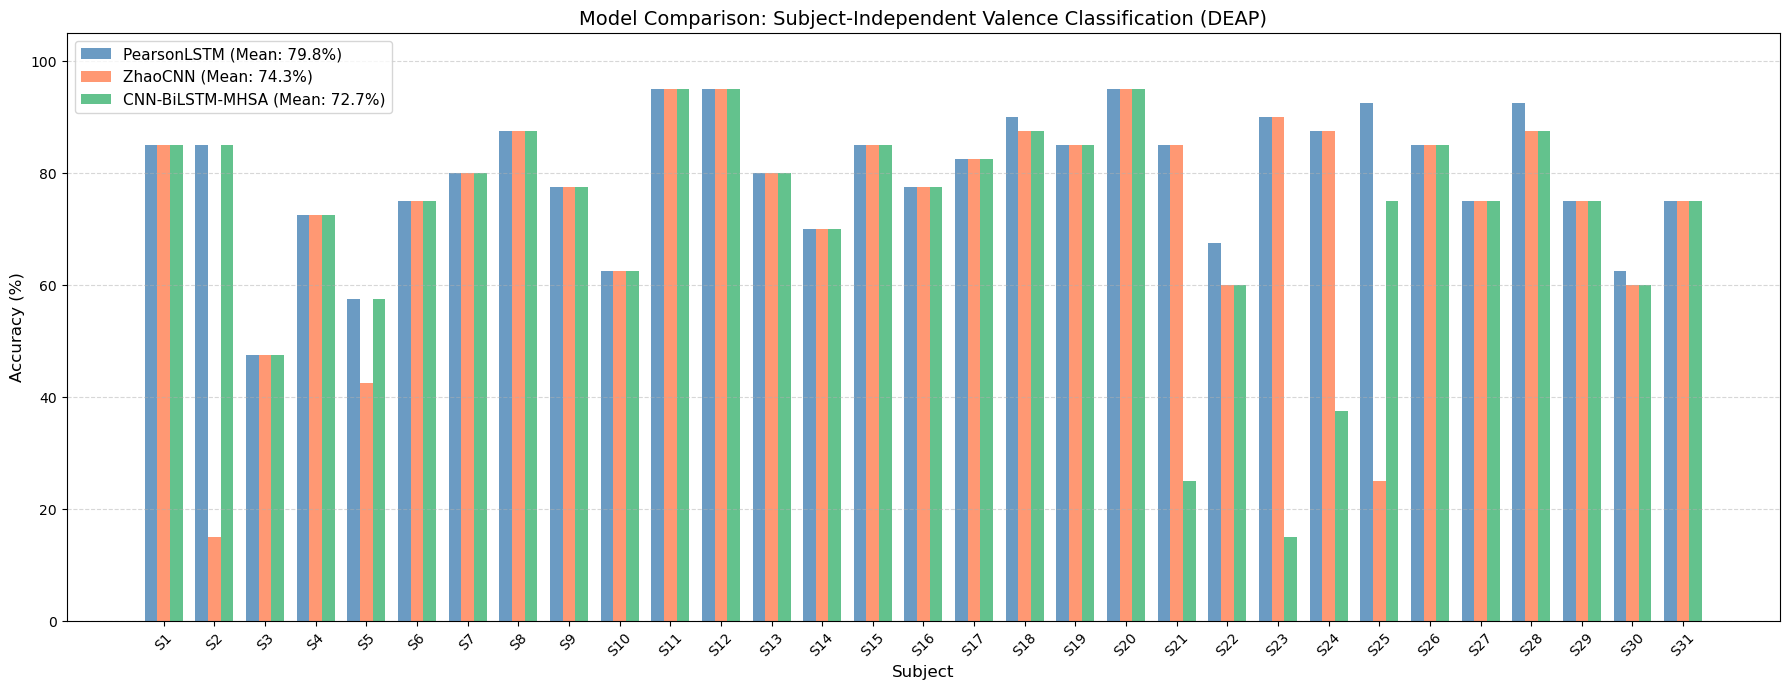


Model Comparison Summary:
Model                       Mean Accuracy      Min      Max
------------------------------------------------------------
PearsonLSTM                        79.76%   47.50%   95.00%
ZhaoCNN                            74.27%   15.00%   95.00%
CNN-BiLSTM-MHSA                    72.66%   15.00%   95.00%


In [37]:
import matplotlib.pyplot as plt
import numpy as np

subjects = [r['Subject'] for r in hybrid_results]
n_subjects = len(subjects)

lstm_accs = [r['Accuracy'] * 100 for r in final_results]
cnn_accs = [r['Accuracy'] * 100 for r in cnn_results]
hybrid_accs = [r['Accuracy'] * 100 for r in hybrid_results]

x = np.arange(n_subjects)
width = 0.25

fig, ax = plt.subplots(figsize=(18, 7))

bars1 = ax.bar(
    x - width, lstm_accs, width, 
    label=f'PearsonLSTM (Mean: {np.mean(lstm_accs):.1f}%)', 
    color='steelblue', alpha=0.8
)
bars2 = ax.bar(
    x, cnn_accs, width, 
    label=f'ZhaoCNN (Mean: {np.mean(cnn_accs):.1f}%)', 
    color='coral', alpha=0.8
)
bars3 = ax.bar(
    x + width, hybrid_accs, width, 
    label=f'CNN-BiLSTM-MHSA (Mean: {np.mean(hybrid_accs):.1f}%)', 
    color='mediumseagreen', alpha=0.8
)

ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(
    'Model Comparison: Subject-Independent Valence Classification (DEAP)',
    fontsize=14
)
ax.set_xticks(x)
ax.set_xticklabels([f'S{s}' for s in subjects], rotation=45)
ax.legend(fontsize=11)
ax.set_ylim(0, 105)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print summary table
print('\nModel Comparison Summary:')
print(f"{'Model':<25} {'Mean Accuracy':>15} {'Min':>8} {'Max':>8}")
print('-' * 60)
print(
    f"{'PearsonLSTM':<25} {np.mean(lstm_accs):>14.2f}% "
    f"{np.min(lstm_accs):>7.2f}% {np.max(lstm_accs):>7.2f}%"
)
print(
    f"{'ZhaoCNN':<25} {np.mean(cnn_accs):>14.2f}% "
    f"{np.min(cnn_accs):>7.2f}% {np.max(cnn_accs):>7.2f}%"
)
print(
    f"{'CNN-BiLSTM-MHSA':<25} {np.mean(hybrid_accs):>14.2f}% "
    f"{np.min(hybrid_accs):>7.2f}% {np.max(hybrid_accs):>7.2f}%"
)

Training model for interpretability (Subject 1 held out)...
Training complete!


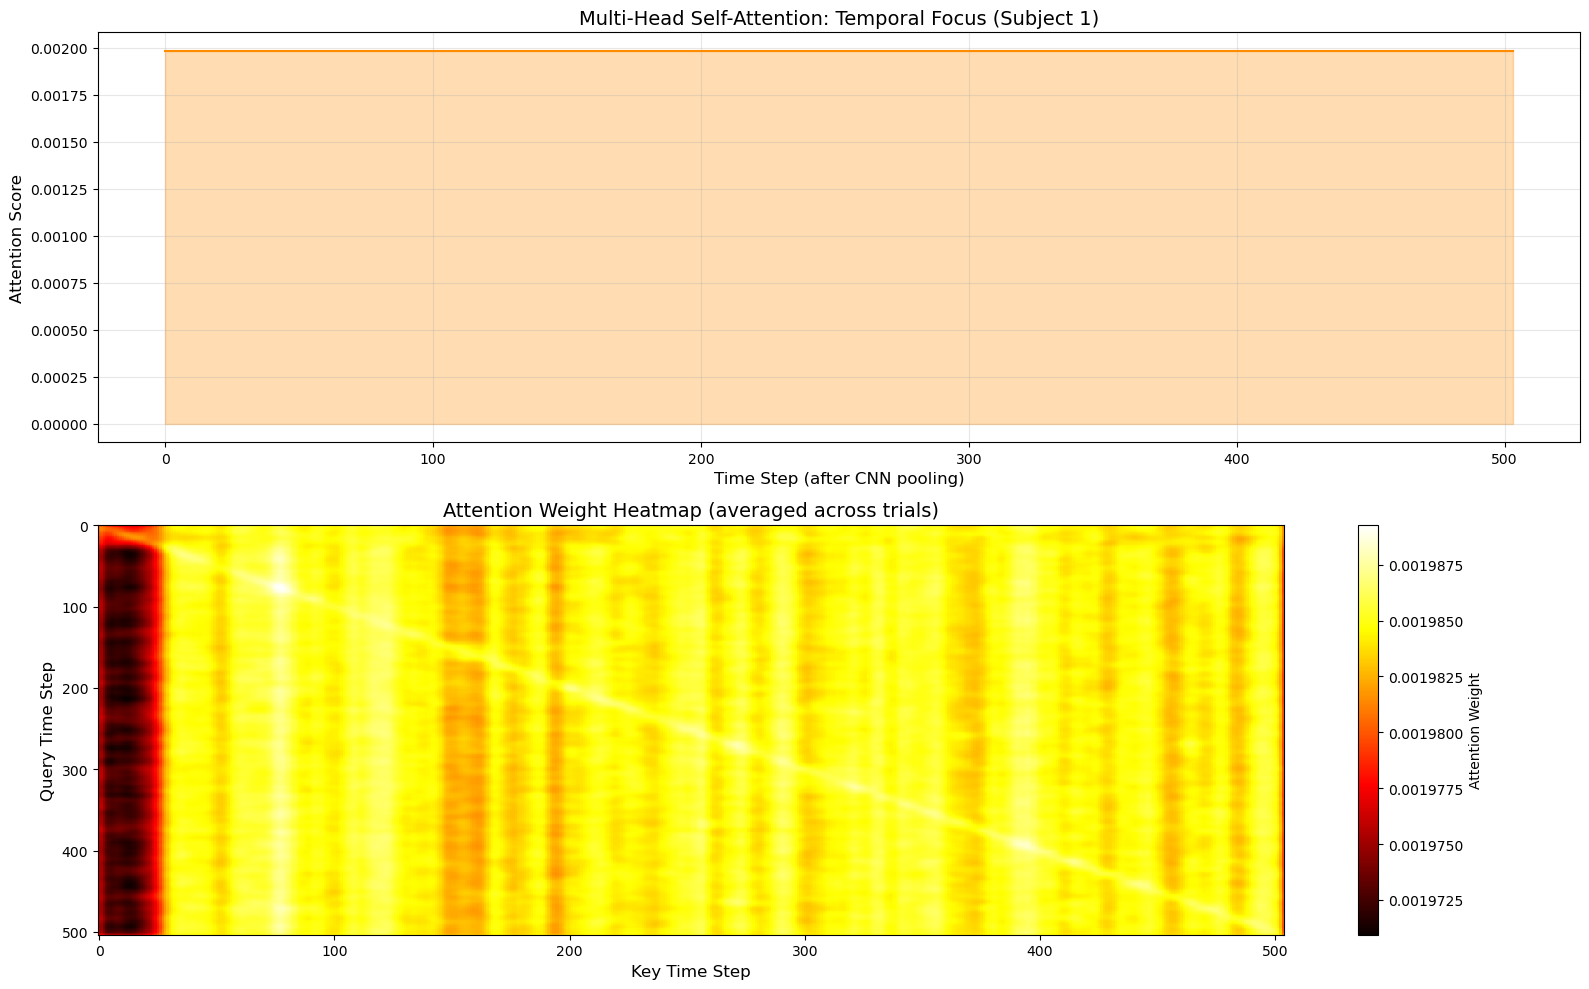


Top 5 most-attended time steps: [389 268 355 370 337]
Prediction for Subject 1: [0.2828326  0.29248974 0.29131472 0.2852005  0.26262105 0.2654105
 0.3197507  0.32063776 0.32513413 0.28739622 0.283993   0.3417165
 0.30524594 0.2804326  0.30376756 0.26517496 0.29415995 0.25134832
 0.3077754  0.2690934  0.27547565 0.30448884 0.2996667  0.27689835
 0.30969653 0.30304852 0.32640985 0.28155503 0.28600466 0.30366313
 0.2633614  0.30163452 0.28414088 0.31182432 0.25831485 0.294019
 0.29788896 0.29783267 0.26953176 0.27684182]


In [38]:
viz_subject = 0
viz_test_idx = np.where(groups_hybrid == viz_subject)[0]

# Get test data for this subject
X_viz = torch.tensor(
    X_flat_hybrid[viz_test_idx], dtype=torch.float32
).cuda()

# Train a quick model for visualization
viz_train_idx = np.where(groups_hybrid != viz_subject)[0]
viz_layers, viz_params = create_hybrid_model(
    in_channels=32, cnn_filters=CNN_FILTERS,
    kernel_size=KERNEL_SIZE, pool_size=POOL_SIZE,
    lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS,
    num_heads=NUM_HEADS, dropout=DROPOUT
)
move_to_gpu(viz_layers)

viz_optimizer = optim.Adam(viz_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
viz_criterion = nn.BCELoss()

X_viz_train = torch.tensor(X_flat_hybrid[viz_train_idx], dtype=torch.float32)
y_viz_train = torch.tensor(
    y_flat_bin_hybrid[viz_train_idx], dtype=torch.float32
).unsqueeze(1)
viz_loader = DataLoader(
    TensorDataset(X_viz_train, y_viz_train), batch_size=BATCH_SIZE, shuffle=True
)

print(f'Training model for interpretability (Subject {viz_subject+1} held out)...')
set_train_mode(viz_layers)
for epoch in range(EPOCHS):
    for batch_X, batch_y in viz_loader:
        batch_X, batch_y = batch_X.cuda(), batch_y.cuda()
        viz_optimizer.zero_grad()
        out = forward_pass(batch_X, viz_layers)
        loss = viz_criterion(out, batch_y)
        loss.backward()
        viz_optimizer.step()
print('Training complete!')

set_eval_mode(viz_layers)
with torch.no_grad():
    preds, attn_weights = forward_pass_with_attention(X_viz, viz_layers)

avg_attn = attn_weights.mean(dim=0).cpu().numpy()  # (seq_len, seq_len)

timestep_importance = avg_attn.mean(axis=1)  # (seq_len,)
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].plot(timestep_importance, color='darkorange', linewidth=1.5)
axes[0].fill_between(
    range(len(timestep_importance)), timestep_importance, 
    alpha=0.3, color='darkorange'
)
axes[0].set_xlabel('Time Step (after CNN pooling)', fontsize=12)
axes[0].set_ylabel('Attention Score', fontsize=12)
axes[0].set_title(
    f'Multi-Head Self-Attention: Temporal Focus (Subject {viz_subject+1})',
    fontsize=14
)
axes[0].grid(True, alpha=0.3)

im = axes[1].imshow(avg_attn, aspect='auto', cmap='hot', interpolation='nearest')
axes[1].set_xlabel('Key Time Step', fontsize=12)
axes[1].set_ylabel('Query Time Step', fontsize=12)
axes[1].set_title('Attention Weight Heatmap (averaged across trials)', fontsize=14)
plt.colorbar(im, ax=axes[1], label='Attention Weight')

plt.tight_layout()
plt.show()

print(f'\nTop 5 most-attended time steps: {np.argsort(timestep_importance)[-5:][::-1]}')
print(f'Prediction for Subject {viz_subject+1}: {preds.cpu().numpy().flatten()}')

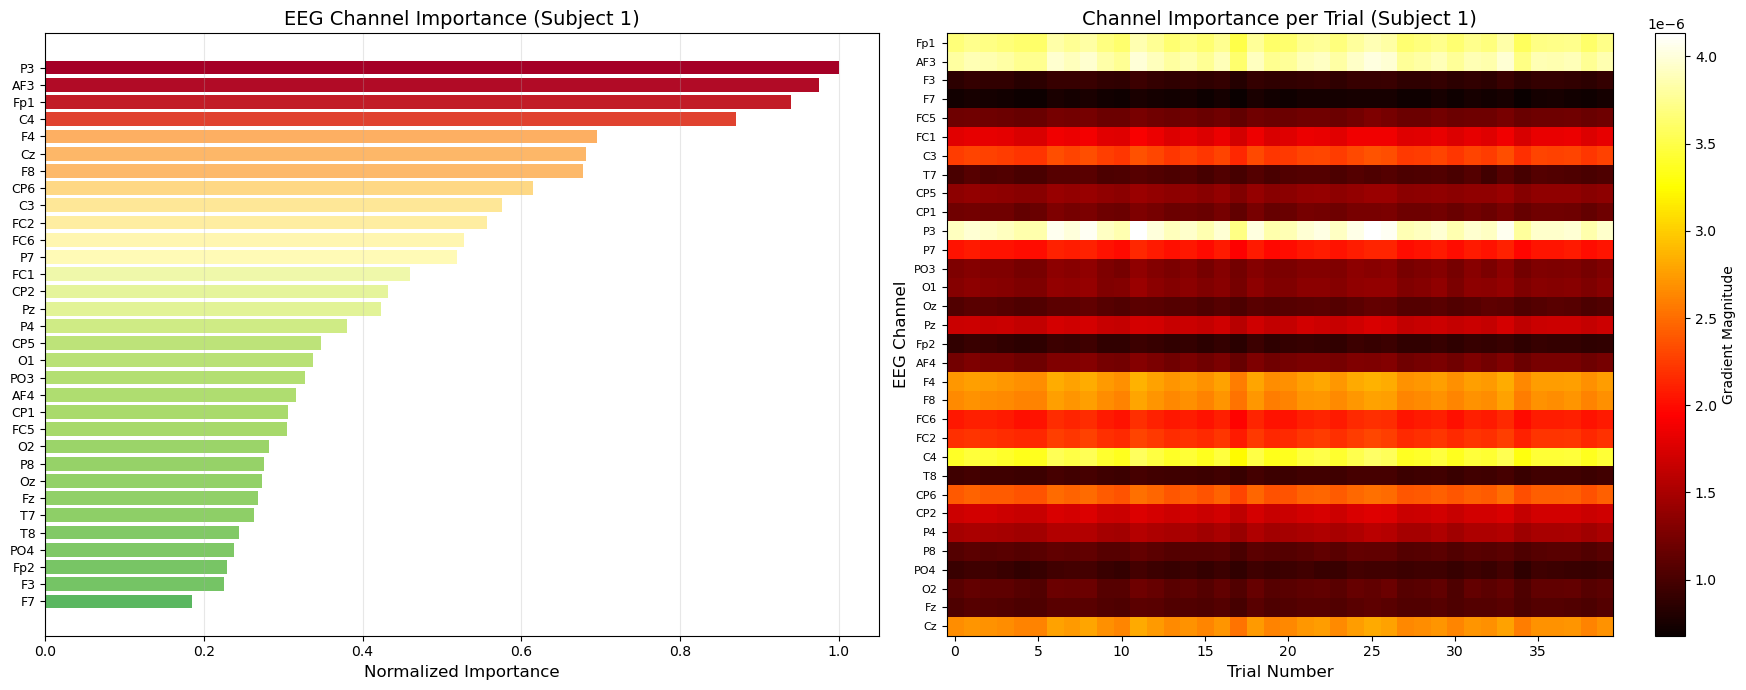


Top 5 most important EEG channels for Subject 1:
  1. P3 (importance: 1.0000)
  2. AF3 (importance: 0.9752)
  3. Fp1 (importance: 0.9392)
  4. C4 (importance: 0.8702)
  5. F4 (importance: 0.6955)

Bottom 5 least important EEG channels:
  T8 (importance: 0.2438)
  PO4 (importance: 0.2383)
  Fp2 (importance: 0.2286)
  F3 (importance: 0.2255)
  F7 (importance: 0.1856)


In [39]:
deap_channels = [
    'Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7',
    'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz',
    'Fp2', 'AF4', 'F4', 'F8', 'FC6', 'FC2', 'C4', 'T8',
    'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'Fz', 'Cz'
]

X_saliency = torch.tensor(
    X_flat_hybrid[viz_test_idx], dtype=torch.float32
).cuda()

channel_importance = compute_saliency(X_saliency, viz_layers)
avg_importance = channel_importance.mean(dim=0).cpu().numpy()  # (32,)
avg_importance = avg_importance / avg_importance.max()
sorted_idx = np.argsort(avg_importance)[::-1]
sorted_channels = [deap_channels[i] for i in sorted_idx]
sorted_values = avg_importance[sorted_idx]
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors = plt.cm.RdYlGn_r(sorted_values)  # Red=important, Green=less important
axes[0].barh(range(len(sorted_channels)), sorted_values, color=colors)
axes[0].set_yticks(range(len(sorted_channels)))
axes[0].set_yticklabels(sorted_channels, fontsize=9)
axes[0].set_xlabel('Normalized Importance', fontsize=12)
axes[0].set_title(
    f'EEG Channel Importance (Subject {viz_subject+1})',
    fontsize=14
)
axes[0].invert_yaxis()  # Most important at top
axes[0].grid(axis='x', alpha=0.3)
trial_importance = channel_importance.cpu().numpy()  # (40, 32)
im = axes[1].imshow(
    trial_importance.T, aspect='auto', cmap='hot', interpolation='nearest'
)
axes[1].set_xlabel('Trial Number', fontsize=12)
axes[1].set_ylabel('EEG Channel', fontsize=12)
axes[1].set_yticks(range(32))
axes[1].set_yticklabels(deap_channels, fontsize=8)
axes[1].set_title(
    f'Channel Importance per Trial (Subject {viz_subject+1})',
    fontsize=14
)
plt.colorbar(im, ax=axes[1], label='Gradient Magnitude')

plt.tight_layout()
plt.show()

print(f'\nTop 5 most important EEG channels for Subject {viz_subject+1}:')
for i in range(5):
    print(f'  {i+1}. {sorted_channels[i]} (importance: {sorted_values[i]:.4f})')

print(f'\nBottom 5 least important EEG channels:')
for i in range(-5, 0):
    print(f'  {sorted_channels[i]} (importance: {sorted_values[i]:.4f})')